### And welcome to Week 4, Day 3 - more LangGraph..

In [13]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict


In [14]:
# Our favorite first step! Crew was doing this for us, by the way.
load_dotenv(override=True)


True

### First, let's go set up LangSmith!

https://langsmith.com

### Next, here is a useful function in LangChain community:

In [15]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

'Paris'

### Now here is a LangChain wrapper class for converting functions into Tools

In [16]:
from langchain.agents import Tool

tool_search =Tool(
        name="search",
        func=serper.run,
        description="Useful for when you need more information from an online search"
    )



### Now we can try out the tool the langchain way

In [17]:
tool_search.invoke("What is the capital of Costa Rica?")

"San José is the capital and largest city of Costa Rica, and the capital of San José Province. It is in the center of the country, in the mid-west of the ... San Jose is the capital of Costa Rica and found in the Central Valley. It has become a modern, cosmopolitan city and is presently home a third of the country's ... San José, capital and largest city of Costa Rica. Situated in the broad, fertile Valle Central 3,800 feet (1,160 metres) above sea level, it was called ... San Jose is the heart of Costa Rica and home to roughly half the country's 4.9 million citizens. It's one of those cities that doesn't wow you from afar. San José, the capital of Costa Rica—along with Managua (Nicaragua) and Brasília (Brazil)—is one of Latin America's youngest capitals. It has a population of around five million in a land area of nearly 51,180 km2 (19,760 sq mi); the capital and largest city is San José, home to around 350,000 ... San José is the capital of Costa Rica and offers a wide variety of cul

### And now let's write a tool ourselves

We'll pick a familiar one

In [18]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [19]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

tool_push.invoke("Hello, me")

### Volvamos al gráfico de ayer

Un pequeño cambio: usar TypedDict en lugar de BaseModel para el objeto State

Cuando implementamos herramientas, siempre tenemos que hacer dos cambios en el código:

1. Cambios para proporcionar las herramientas a OpenAI en formato JSON cuando realizamos la llamada

2. Cambios para gestionar los resultados: buscar el modelo en el que finish_reason=="tool_calls" y, a continuación, recuperar la llamada, ejecutar la función y proporcionar los resultados.



### Bring them together

In [20]:
tools = [tool_search, tool_push]

In [21]:
# Step 1: Define the State object
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [22]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)

In [23]:
# This is different:

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [24]:
# Step 3: Create a Node


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [25]:
# Step 4: Create Edges


graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")

# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

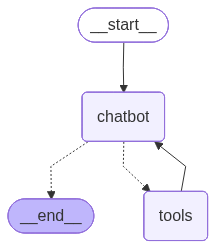

In [26]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! And, let's do this:

In [27]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## ¡Vale, es hora de añadir memoria!

### ¡Pero espera!

Tenemos todo este grafo que mantiene el estado y le añade datos.

¿Por qué no gestiona esto la memoria?

### Este es un punto crucial para entender LangGraph

> Un superpaso puede considerarse una única iteración sobre los nodos del grafo. Los nodos que se ejecutan en paralelo forman parte del mismo superpaso, mientras que los nodos que se ejecutan secuencialmente pertenecen a superpasos separados.


Un «superpaso» del grafo representa una invocación de intercambio de mensajes entre agentes.

En LangGraph idiomático, se llama a invoke para ejecutar el grafo en cada superpaso; para cada interacción.

El reductor gestiona las actualizaciones de estado automáticamente dentro de un superpaso, pero no entre ellos.

Eso es lo que consigue el checkpointing.



In [28]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

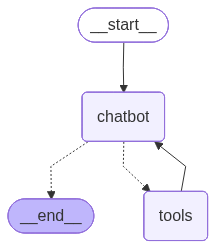

In [29]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hOLA', additional_kwargs={}, response_metadata={}, id='5a9aa186-2c1a-4abc-a855-fe35f7f37c13'), AIMessage(content='¡Hola! ¿Cómo puedo ayudarte hoy?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 90, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fa616991a3', 'id': 'chatcmpl-DYFSXl90VdrVIOZkgmblTsZfrmiOq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--087679b5-bff8-4faa-862d-795857b86b5f-0', usage_metadata={'input_tokens': 90, 'output_tokens': 10, 'total_tokens': 100, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content='Me llamo Kev

In [37]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hOLA', additional_kwargs={}, response_metadata={}, id='5a9aa186-2c1a-4abc-a855-fe35f7f37c13'), AIMessage(content='¡Hola! ¿Cómo puedo ayudarte hoy?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 90, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fa616991a3', 'id': 'chatcmpl-DYFSXl90VdrVIOZkgmblTsZfrmiOq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--087679b5-bff8-4faa-862d-795857b86b5f-0', usage_metadata={'input_tokens': 90, 'output_tokens': 10, 'total_tokens': 100, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(

In [38]:
# Most recent first

list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='hOLA', additional_kwargs={}, response_metadata={}, id='5a9aa186-2c1a-4abc-a855-fe35f7f37c13'), AIMessage(content='¡Hola! ¿Cómo puedo ayudarte hoy?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 90, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fa616991a3', 'id': 'chatcmpl-DYFSXl90VdrVIOZkgmblTsZfrmiOq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--087679b5-bff8-4faa-862d-795857b86b5f-0', usage_metadata={'input_tokens': 90, 'output_tokens': 10, 'total_tokens': 100, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage

### LangGraph gives you tools to set the state back to a prior point in time, to branch off:

```
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

And this allows you to build stable systems that can be recovered and rerun from any prior checkpoint.

### And now let's store in SQL

### And this is the power of LangGraph.

In [45]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

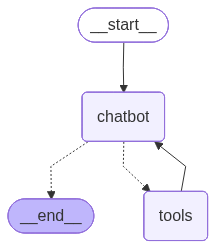

In [46]:
# Steps 1 and 2
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [ ]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='d6144090-9963-438c-b21b-3fb4f06edbc0'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 90, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b376dfbbd5', 'id': 'chatcmpl-BInN7JUnEYNTQqokCF3eihp5oKP0V', 'finish_reason': 'stop', 'logprobs': None}, id='run-4b488710-73ac-435e-a944-913a0c812d08-0', usage_metadata={'input_tokens': 90, 'output_tokens': 11, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content="what's my name", additional_kwargs